In [1]:
# Importing Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Importing MNIST Dataset from torchvision
training_set = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Importing Validation Set from torchvision
validation_set = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

# Creating data loaders
training_loader = DataLoader(training_set, batch_size=100, shuffle=True)
validation_loader = DataLoader(validation_set, batch_size=100, shuffle=False)

# Class labels
classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

# Report split sizes
print(f'Training set: {len(training_set)}')
print(f'Validation set: {len(validation_set)}')

Training set: 60000
Validation set: 10000


4  7  4  5


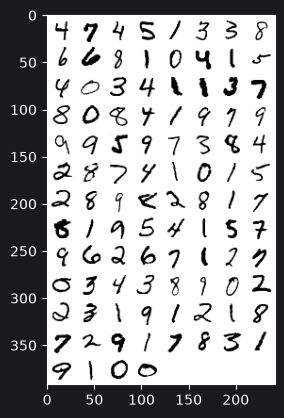

In [3]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [4]:
# Defining my very first neural network
class SimpleNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x = torch.flatten(x,1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x
model = SimpleNeuralNetwork()
device ='cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [5]:
# Defining Loss Function (Since it is a multi-class classification, I chose CrossEntropyLoss)
loss_fn = nn.CrossEntropyLoss()
# Defining Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [8]:
# Setup optimization loop(s)
epochs = 100

### Train time
# Loop through the epochs
for epoch in range(epochs):
    train_loss_total = 0
    test_loss_total = 0
    train_correct_guess_total = 0
    test_correct_guess_total = 0
    # Set the model to train mode (this is the default)
    model.train(True)
    for images, labels in training_loader:
        images = images.to(device)
        labels = labels.to(device)
        # 1. Do the forward pass
        y_pred = model(images)
        predicted_labels = y_pred.argmax(dim=1)
        train_correct_guess_total += (predicted_labels == labels).sum().item()
        # 2. Calculate the loss (how wrong the model is)
        loss = loss_fn(y_pred, labels)
        # 3. Zero the optimizer gradients
        optimizer.zero_grad()
        # 4. Perform backpropagation
        loss.backward()
        # 5. Step the optimizer
        optimizer.step()
        train_loss_total += loss.item() * images.size(0)
    training_accuracy = (train_correct_guess_total / len(training_set)) * 100
    train_loss_total /= len(training_set)
    ### Test time
    # Set the model to eval mode
    model.eval()
    # Turn on inference mode context manager
    with torch.inference_mode():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)
            # 1. Do the forward pass
            test_pred = model(images)
            predicted_labels = test_pred.argmax(dim=1)
            test_correct_guess_total += (predicted_labels == labels).sum().item()
            # 2. Calculate the loss
            test_loss = loss_fn(test_pred, labels)
            test_loss_total += test_loss.item() * images.size(0)
    test_accuracy = (test_correct_guess_total / len(validation_set)) * 100
    test_loss_total /= len(validation_set)

    # Print out what's happening
    print(f"Epoch: {epoch + 1} | Train loss: {train_loss_total:.4f} | Test loss: {test_loss_total:.4f} | Training Accuracy: {training_accuracy:.2f} % | Test Accuracy: {test_accuracy:.2f} % ")

Epoch: 1 | Train loss: 0.0801 | Test loss: 0.0970 | Training Accuracy: 97.78 % | Test Accuracy: 97.12 % 
Epoch: 2 | Train loss: 0.0794 | Test loss: 0.0962 | Training Accuracy: 97.82 % | Test Accuracy: 97.12 % 
Epoch: 3 | Train loss: 0.0786 | Test loss: 0.0965 | Training Accuracy: 97.85 % | Test Accuracy: 97.14 % 
Epoch: 4 | Train loss: 0.0781 | Test loss: 0.0952 | Training Accuracy: 97.85 % | Test Accuracy: 97.12 % 
Epoch: 5 | Train loss: 0.0774 | Test loss: 0.0949 | Training Accuracy: 97.86 % | Test Accuracy: 97.13 % 
Epoch: 6 | Train loss: 0.0768 | Test loss: 0.0949 | Training Accuracy: 97.86 % | Test Accuracy: 97.14 % 
Epoch: 7 | Train loss: 0.0761 | Test loss: 0.0945 | Training Accuracy: 97.94 % | Test Accuracy: 97.16 % 
Epoch: 8 | Train loss: 0.0755 | Test loss: 0.0936 | Training Accuracy: 97.92 % | Test Accuracy: 97.16 % 
Epoch: 9 | Train loss: 0.0749 | Test loss: 0.0931 | Training Accuracy: 97.94 % | Test Accuracy: 97.22 % 
Epoch: 10 | Train loss: 0.0743 | Test loss: 0.0930 | Tr

In [7]:
torch.save(model.state_dict(), 'simple_neural_network.pth')